# Serie Temporal Bitcoin

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [6]:
Bitcoin_A = pd.read_excel("bitcoin_A.xlsx")
Bitcoin_A['DIA'] = pd.to_datetime(Bitcoin_A['DIA'], format='%Y-%m-%d')
Bitcoin_A.head()

,DIA,PRECIO,N_TRANS
0,2018-09-18,6296.631667,244259
1,2018-09-19,6335.826667,251037
2,2018-09-20,6418.562667,253674
3,2018-09-21,6669.990833,273051
4,2018-09-22,6709.312500,225537


In [7]:
print(f'\nRango de fechas: {Bitcoin_A.DIA.min()}/{ Bitcoin_A.DIA.max()}')


Rango de fechas: 2018-09-18 00:00:00/2019-09-17 00:00:00


                 PRECIO  N_TRANS
DIA                             
2018-09-18  6296.631667   244259
2018-09-19  6335.826667   251037
2018-09-20  6418.562667   253674
2018-09-21  6669.990833   273051
2018-09-22  6709.312500   225537


(array([17775., 17836., 17897., 17956., 18017., 18078., 18140.]),
 [Text(17775.0, 0, '2018-09'),
  Text(17836.0, 0, '2018-11'),
  Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05'),
  Text(18078.0, 0, '2019-07'),
  Text(18140.0, 0, '2019-09')])

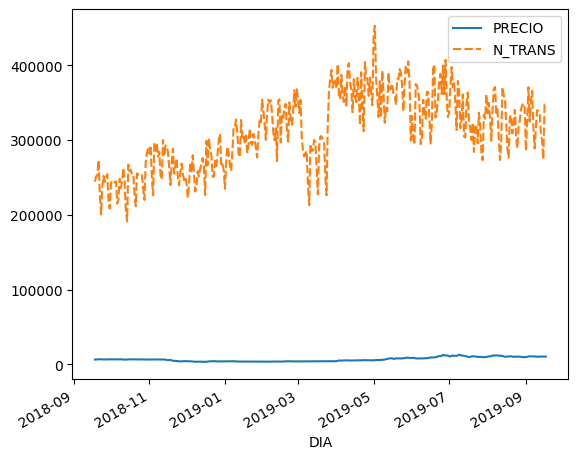

In [8]:
# se establece la columna fecha como índice y se elimina
Bitcoin_A.index = Bitcoin_A['DIA']
del Bitcoin_A['DIA']
print(Bitcoin_A.head())
sns.lineplot(Bitcoin_A)
plt.xticks(rotation=30, ha='right')

(array([17775., 17836., 17897., 17956., 18017., 18078., 18140.]),
 [Text(17775.0, 0, '2018-09'),
  Text(17836.0, 0, '2018-11'),
  Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05'),
  Text(18078.0, 0, '2019-07'),
  Text(18140.0, 0, '2019-09')])

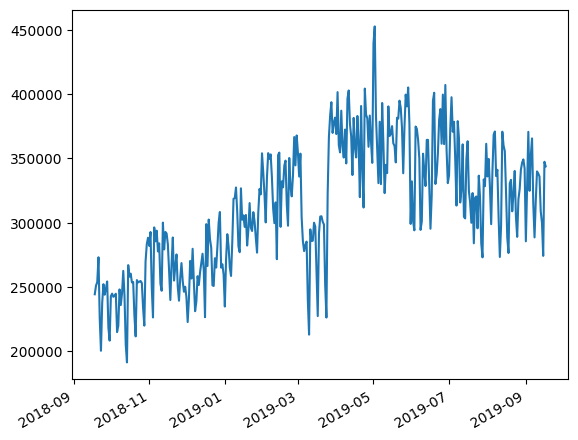

In [9]:
plt.plot(Bitcoin_A["N_TRANS"])
plt.xticks(rotation=30, ha='right')

(array([17775., 17836., 17897., 17956., 18017., 18078., 18140.]),
 [Text(17775.0, 0, '2018-09'),
  Text(17836.0, 0, '2018-11'),
  Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05'),
  Text(18078.0, 0, '2019-07'),
  Text(18140.0, 0, '2019-09')])

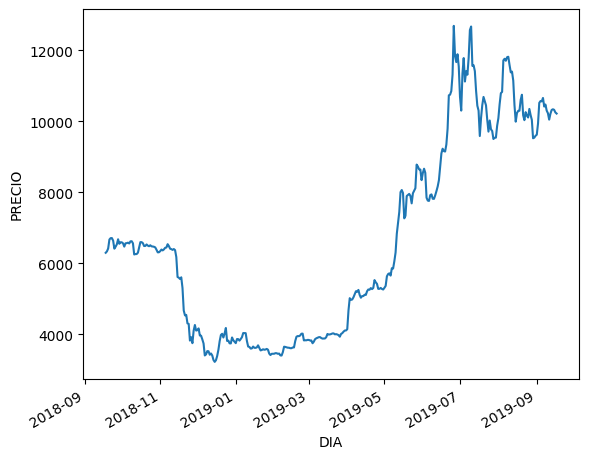

In [11]:
sns.lineplot(Bitcoin_A["PRECIO"])
plt.xticks(rotation=30, ha='right')

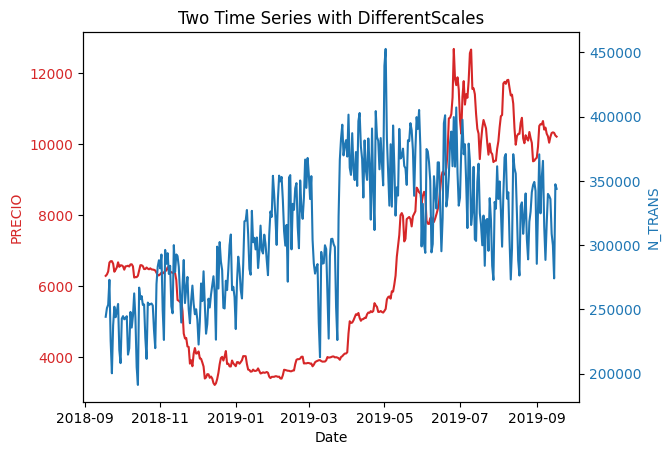

In [12]:
# 1. Crear un gráfico con dos ejes y compartir el eje x
fig, ax1 = plt.subplots()

# 2. Primera serie en el eje izquierdo (ax1)
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('PRECIO', color=color)
ax1.plot(Bitcoin_A['PRECIO'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

# 3. Segunda serie en el eje derecho (ax2)
ax2 = ax1.twinx() # Compartir el eje x
color = 'tab:blue'
ax2.set_ylabel('N_TRANS', color=color)
ax2.plot(Bitcoin_A['N_TRANS'],
color=color)
ax2.tick_params(axis='y', labelcolor=color)

# 4. Ajustes de diseño
plt.title('Two Time Series with DifferentScales')
plt.show()

# Modelo de Alisado Simple

In [13]:
import statsmodels.api as sm
precio_R = Bitcoin_A.PRECIO.loc['2019-08-01':]
precio_R.index.freq = 'D'
# Aplicar suavizado exponencial simple.
modelo_ses = sm.tsa.SimpleExpSmoothing(precio_R , initialization_method="estimated").fit()
# Para seleccionar distintas alphas, fit(smoothing_level=alpha)
# Calcular la predicción para 7 días.
precio_s1 = modelo_ses.forecast(steps=7)
# Para ver parámetros, e.g.: alpha = 0.995
modelo_ses.summary()

Dep. Variable:,PRECIO,No. Observations:,48
Model:,SimpleExpSmoothing,SSE,3504993.158
Optimized:,True,AIC,541.528
Trend:,None,BIC,545.270
Seasonal:,None,AICC,542.458
Seasonal Periods:,None,Date:,"Fri, 08 May 2026"
Box-Cox:,False,Time:,18:41:21
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
initial_level,10088.805,l.0,True


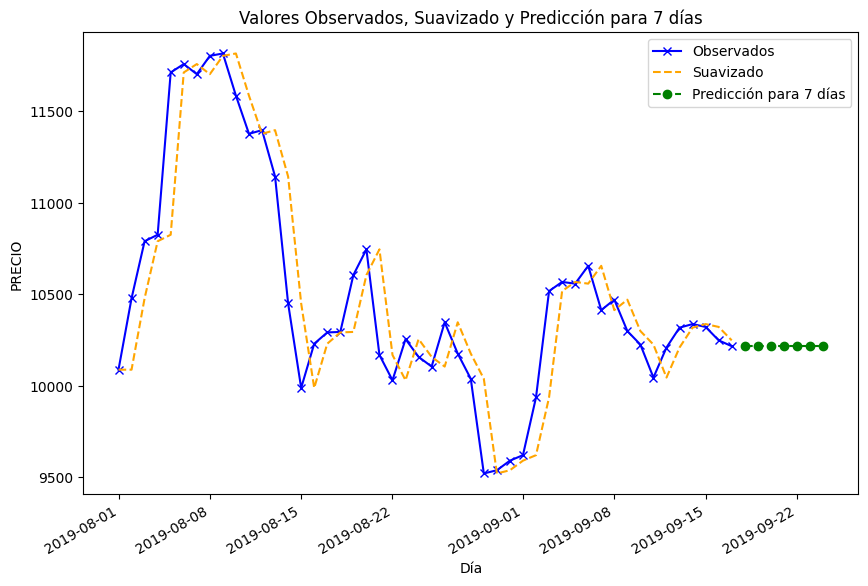

In [16]:
# Crear un gráfico con matplotlib
plt.figure(figsize=(10, 6))
# Valores observados
plt.plot(precio_R.index, precio_R, label='Observados', marker='x', linestyle='-', color='blue')
# Valores suavizados (fitted)
plt.plot(precio_R.index, modelo_ses.fittedvalues, label='Suavizado', linestyle='--', color='orange')
# Predicción para 7 días
plt.plot(precio_s1.index, precio_s1, label='Predicción para 7 días', linestyle='--', marker='o',
color='green')
plt.xlabel('Día')
plt.ylabel('PRECIO')
plt.title('Valores Observados, Suavizado y Predicción para 7 días')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()

# Modelo Alisado Doble

In [18]:
# Aplicar suavizado exponencial doble (Holt).
modelo_holt = sm.tsa.ExponentialSmoothing(precio_R, trend='add', damped=False).fit()
# Obtener predicciones para 7 días
predicciones = modelo_holt.forecast(steps=7)
# Mostrar la descripción del modelo
modelo_holt.summary()
# para controlar los valores de alpha y beta: .fit(smooothing_level = alpha, smoothing_slope = beta, optimized = False)

C:\Users\eloyc\AppData\Local\Temp\ipykernel_31176\977517322.py:2: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  modelo_holt = sm.tsa.ExponentialSmoothing(precio_R, trend='add', damped=False).fit()


Dep. Variable:,PRECIO,No. Observations:,48
Model:,ExponentialSmoothing,SSE,3504642.367
Optimized:,True,AIC,545.523
Trend:,Additive,BIC,553.008
Seasonal:,None,AICC,547.572
Seasonal Periods:,None,Date:,"Fri, 08 May 2026"
Box-Cox:,False,Time:,18:49:43
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.000000,beta,True


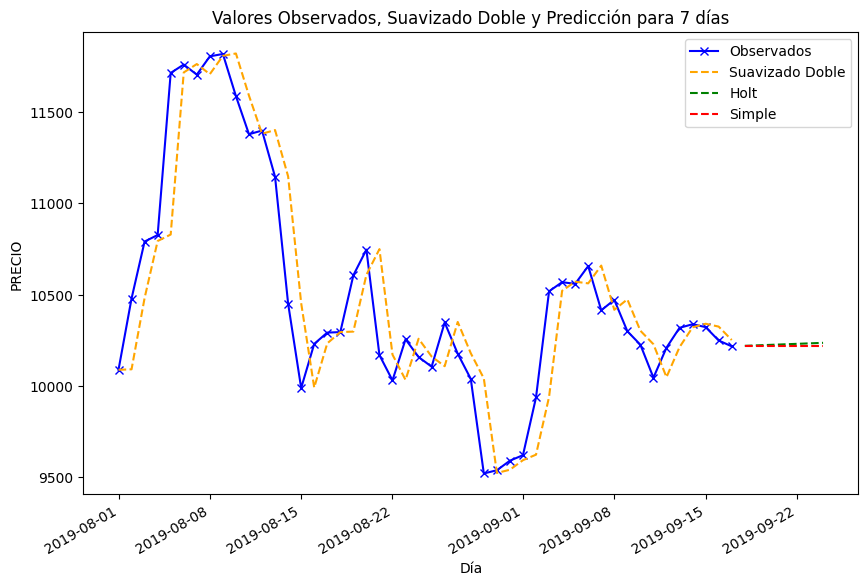

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(precio_R.index, precio_R, label='Observados',
marker='x', linestyle='-', color='blue')
plt.plot(precio_R.index, modelo_holt.fittedvalues,
label='Suavizado Doble', linestyle='--', color='orange')
plt.plot(predicciones.index, predicciones, label='Holt',
linestyle='--',color='green')
plt.plot(precio_s1.index, precio_s1, label='Simple',
linestyle='--', color='red')
plt.xlabel('Día')
plt.ylabel('PRECIO')
plt.title('Valores Observados, Suavizado Doble y Predicción para 7 días')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()

# Modelo de Alisado Holt-Winters